# 02 — Chain-of-Thought vs Direct Answer

## Goal

Does asking the model to **reason before answering** help or hurt 5-way ordinal classification on Yelp?

Two schemas, same 500 eval rows, same model (`ACTIVE_CLASSIFIER` = DeepSeek V3.2 from notebook 01):

| Strategy | Schema | Expected effect |
|---|---|---|
| direct | `{stars}` only | Baseline: model emits just a star count |
| cot | `{reasoning, stars}` | Reasoning field forces structured thinking first |

## Hypothesis

- CoT likely helps on **middle classes (3★, 4★)** where sentiment is mixed and needs weighing.
- CoT may **hurt 5★** via over-qualification (model finds a nit, drops to 4).
- **Reasoning/answer mismatch**: sometimes reasoning text says '5 stars' but field emits '3'. We count these.

## Metric focus

Standard 4 + per-class Δ and mismatch rate.

In [1]:
import sys; sys.path.insert(0, '..')
import asyncio, json, re, time
from pathlib import Path
import pandas as pd

from lib.config import ACTIVE_CLASSIFIER
from lib.gateway import classify_json
from lib.schemas import StarsDirect, StarsCoT
from lib.prompts import CLASSIFIER_SYSTEM, CLASSIFIER_SYSTEM_COT, direct, cot
from lib.datasets import read_jsonl
from lib.concurrency import gather_limited
from lib.metrics import Prediction, report, fmt
from lib.plots import confusion_heatmap

CLASSES = [1, 2, 3, 4, 5]
eval_set = read_jsonl('../data/yelp_eval.jsonl')
print('model:', ACTIVE_CLASSIFIER)
print('eval n:', len(eval_set))

model: deepseek/deepseek-v3.2
eval n: 500


## Inspect both prompts

In [2]:
sample = eval_set[0]
print('truth:', sample['stars'], '★\n')
print('--- direct ---'); print(direct(sample['text'])[:300])
print('\n--- cot ---'); print(cot(sample['text'])[:300])

truth: 4 ★

--- direct ---
Review: I really enjoy what the Hale Center Theater brings.  I have seen some great performances and have been surprised at how well the scenary is done and the actors perform.  It is definitely worth it.  So happy Gilbert offers this.

What is the star rating (1-5)?

--- cot ---
Review: I really enjoy what the Hale Center Theater brings.  I have seen some great performances and have been surprised at how well the scenary is done and the actors perform.  It is definitely worth it.  So happy Gilbert offers this.

Reason through the sentiment signals, then output the star rati


## Run both strategies

In [3]:
async def run_direct(row):
    obj, _ = await classify_json(StarsDirect, CLASSIFIER_SYSTEM, direct(row['text']))
    return Prediction(pred=obj.stars if obj else None, truth=row['stars'])

async def run_cot(row):
    obj, _ = await classify_json(StarsCoT, CLASSIFIER_SYSTEM_COT, cot(row['text']))
    return Prediction(pred=obj.stars if obj else None, truth=row['stars'], extra={'reasoning': obj.reasoning if obj else None})

t0 = time.time(); direct_preds = await gather_limited(eval_set, run_direct, 30, 'direct'); td = time.time() - t0
t0 = time.time(); cot_preds    = await gather_limited(eval_set, run_cot,    30, 'cot');    tc = time.time() - t0

r_d = report(direct_preds, CLASSES); r_c = report(cot_preds, CLASSES)
print('\ndirect:', fmt(r_d).split(chr(10))[0], f'  t={td:.1f}s')
print('cot:   ', fmt(r_c).split(chr(10))[0], f'  t={tc:.1f}s')

direct:   0%|          | 0/500 [00:00<?, ?it/s]

direct:   0%|          | 1/500 [00:01<13:59,  1.68s/it]

direct:   1%|          | 5/500 [00:01<02:15,  3.66it/s]

direct:   4%|▍         | 21/500 [00:01<00:25, 18.51it/s]

direct:   6%|▌         | 30/500 [00:02<00:19, 23.67it/s]

...

cot: 100%|█████████▉| 498/500 [01:21<00:00,  5.06it/s]

cot: 100%|█████████▉| 499/500 [01:21<00:00,  5.42it/s]

cot: 100%|██████████| 500/500 [01:21<00:00,  4.73it/s]

cot: 100%|██████████| 500/500 [01:21<00:00,  6.14it/s]


direct: n=500  compliance=100.0%  accuracy=64.2%  macroF1=0.634  MAE=0.370   t=29.0s
cot:    n=500  compliance=100.0%  accuracy=62.8%  macroF1=0.613  MAE=0.394   t=81.5s


## Per-class delta (cot - direct)

In [4]:
def per_class_acc(preds, classes):
    out = {}
    for c in classes:
        same = [p for p in preds if p.truth == c]
        hit = sum(1 for p in same if p.pred == c)
        out[c] = hit / max(1, len(same))
    return out

d_acc = per_class_acc(direct_preds, CLASSES)
c_acc = per_class_acc(cot_preds, CLASSES)
rows = [{'stars': c, 'direct': round(d_acc[c]*100, 1), 'cot': round(c_acc[c]*100, 1), 'delta_pp': round((c_acc[c]-d_acc[c])*100, 1)} for c in CLASSES]
pd.DataFrame(rows)

,stars,direct,cot,delta_pp
0,1,84.0,84.0,0.0
1,2,59.0,64.0,5.0
2,3,52.0,47.0,-5.0
3,4,41.0,30.0,-11.0
4,5,85.0,89.0,4.0


## Reasoning / answer mismatches

Count rows where CoT reasoning text mentions an integer 1–5 (e.g., '5 stars', '3/5') that conflicts with the emitted `stars` field.

In [5]:
pat = re.compile(r'(\b[1-5])\s*(?:stars?|/\s*5|\-?star)', re.IGNORECASE)
mismatches = []
for p in cot_preds:
    if p.pred is None or not (p.extra and p.extra.get('reasoning')): continue
    m = pat.search(p.extra['reasoning'])
    if m and int(m.group(1)) != p.pred:
        mismatches.append((int(m.group(1)), p.pred, p.extra['reasoning'][:160]))
print(f'reasoning-vs-answer mismatches: {len(mismatches)} / {sum(1 for p in cot_preds if p.pred is not None)}')
for claim, pred, txt in mismatches[:5]:
    print(f'  said {claim}★, emitted {pred}★: {txt}')

reasoning-vs-answer mismatches: 14 / 500
  said 5★, emitted 2★: Reviewer expresses initial excitement about a new tiki bar but finds the experience disappointing. Positive signals: server effort (5 stars personally), appreci
  said 2★, emitted 3★: The review notes negative aspects: burgers overcooked (well-done vs. ordered medium), tater tots overly salty and chip-like, initial impulse to give 2 stars. Ho
  said 4★, emitted 2★: Positive signals: great desserts, potential for 4 stars. Negative signals: service described as 'LAME,' slow, non-attentive, rude; service is a significant draw
  said 5★, emitted 2★: Review expresses consistent mediocrity: food quality varies (sauce inconsistency), overall 'just OK' across food, price, service (except one server). Major nega
  said 5★, emitted 3★: The reviewer has a long history with the restaurant and initially loved it, praising the atmosphere, service, and specific dishes like the teryaki chicken and T


## Confusion matrices side-by-side

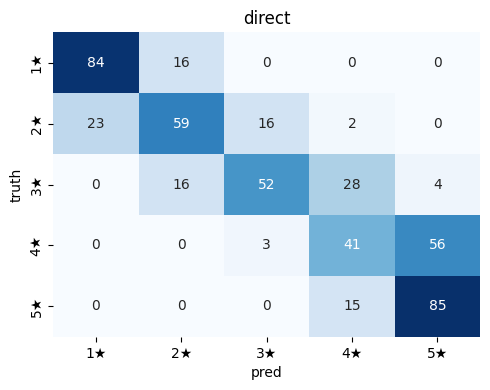

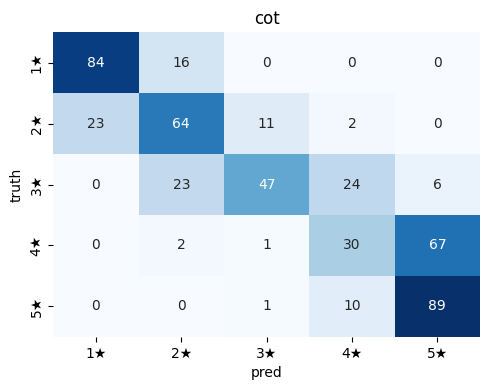

In [6]:
import matplotlib.pyplot as plt
Path('../results/plots').mkdir(parents=True, exist_ok=True)
confusion_heatmap(r_d['confusion'], CLASSES, title='direct', save='../results/plots/02_conf_direct.png'); plt.show()
confusion_heatmap(r_c['confusion'], CLASSES, title='cot',    save='../results/plots/02_conf_cot.png');    plt.show()

## Sample reasoning traces

In [7]:
for i in [0, 100, 200, 300, 400]:
    p = cot_preds[i]
    if p.extra and p.extra.get('reasoning'):
        mark = '✅' if p.pred == p.truth else '❌'
        print(f'{mark}  truth={p.truth}★  pred={p.pred}★')
        print(f'   reasoning: {p.extra["reasoning"][:300]}\n')

❌  truth=4★  pred=5★
   reasoning: The review expresses strong positive sentiment with phrases like 'really enjoy,' 'great performances,' 'surprised at how well,' 'definitely worth it,' and 'So happy.' There are no negative signals; the tone is enthusiastic and appreciative. Overall stance is highly favorable, indicating an excellent

✅  truth=2★  pred=2★
   reasoning: Reviewer expresses strong negative signals: dislikes chain Mexican restaurants, finds decor 'nauseating' and 'tacky', describes salsa as 'thin' and 'nothing special', had order mix-up with sauce, found green sauce disappointing and scraped it off. Positive signals: appreciates bottomless chips, tama

❌  truth=4★  pred=5★
   reasoning: The review starts with a negative signal about poor attendance, but quickly shifts to a highly positive personal experience: 'thoroughly enjoyed it even the 2nd time round,' 'prime front center seats,' and noticing new details. The overall stance is enthusiastic and satisfied, with the init

In [8]:
out = {
    'model': ACTIVE_CLASSIFIER,
    'direct': r_d,
    'cot': r_c,
    'per_class': rows,
    'mismatches': len(mismatches),
    'time_s': {'direct': td, 'cot': tc},
}
Path('../results').mkdir(exist_ok=True)
Path('../results/02_cot_vs_direct.json').write_text(json.dumps(out, indent=2))
print('wrote results/02_cot_vs_direct.json')

wrote results/02_cot_vs_direct.json


## Findings (fill in after run)

- CoT Δ on overall accuracy
- Per-class: where did reasoning help vs hurt?
- Mismatch count as reasoning-fidelity proxy

Next: `03_multi_objective.ipynb`.